## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Dependency for chart label placement — installs itself if missing
try:
    from adjustText import adjust_text
except ImportError:
    %pip install adjustText -q
    from adjustText import adjust_text

DATA_PATH = 'data/reviews_prepared.csv'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f"{len(df):,} reviews | {df['title_clean'].nunique()} games | {df['date'].min().date()} -> {df['date'].max().date()}")

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})
C_POS, C_NEG, C_HI, C_MUT = '#2a9d8f', '#e76f51', '#e9c46a', '#9aa5b1'

def save(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}.png', bbox_inches='tight', dpi=150)
    print(f'saved figures/{name}.png')

14,617 reviews | 23 games | 2010-12-20 -> 2019-02-16


In [2]:
# Per-game summary table used throughout (engagement pipeline: all rows)
g = (df.groupby('title_clean')
       .agg(n_reviews=('rec', 'size'),
            pos_rate=('rec', 'mean'),
            first_review=('date', 'min'),
            last_review=('date', 'max'),
            confidence=('confidence_tier', 'first'))
       .sort_values('n_reviews', ascending=False))

# Median hours computed on the playtime-eligible subset (zero-hour rows excluded — see notebook 01)
g['median_hours'] = df[df['use_playtime']].groupby('title_clean')['hour_played'].median()
g['span_years'] = ((g['last_review'] - g['first_review']).dt.days / 365).round(1)
g.round(3)

,n_reviews,pos_rate,first_review,last_review,confidence,median_hours,span_years
title_clean,,,,,,,
PLAYERUNKNOWN'S BATTLEGROUNDS,2539,0.683,2017-03-23,2019-02-13,High,238.0,1.9
Rust,2291,0.664,2013-12-11,2019-02-10,High,187.5,5.2
Grand Theft Auto V,2174,0.632,2015-04-13,2019-02-16,High,184.0,3.8
Rocket League,1773,0.606,2015-07-07,2019-02-13,High,185.0,3.6
Dead by Daylight,1034,0.631,2016-06-14,2019-02-09,High,112.0,2.7
The Elder Scrolls V: Skyrim Special Edition,977,0.639,2016-10-27,2019-02-02,High,55.5,2.3
MONSTER HUNTER: WORLD,774,0.601,2018-08-09,2019-02-16,High,108.0,0.5
ASTRONEER,577,0.861,2016-12-15,2019-02-13,High,29.0,2.2
RESIDENT EVIL 2 / BIOHAZARD RE:2,496,0.986,2019-01-24,2019-02-16,High,21.0,0.1


### Questions this notebooks wants to answer

1. Does popularity (review volume) actually track approval?
2. What does playtime add that a thumbs-up/down can't show?
3. Are lifetime averages even safe to use — is sentiment stable over time?
4. Which games are gaining or losing steam right now?
5. Do the zero-hour reviews behave like everyone else's?


## Does popularity track approval?


saved figures/01_popularity_vs_positivity.png


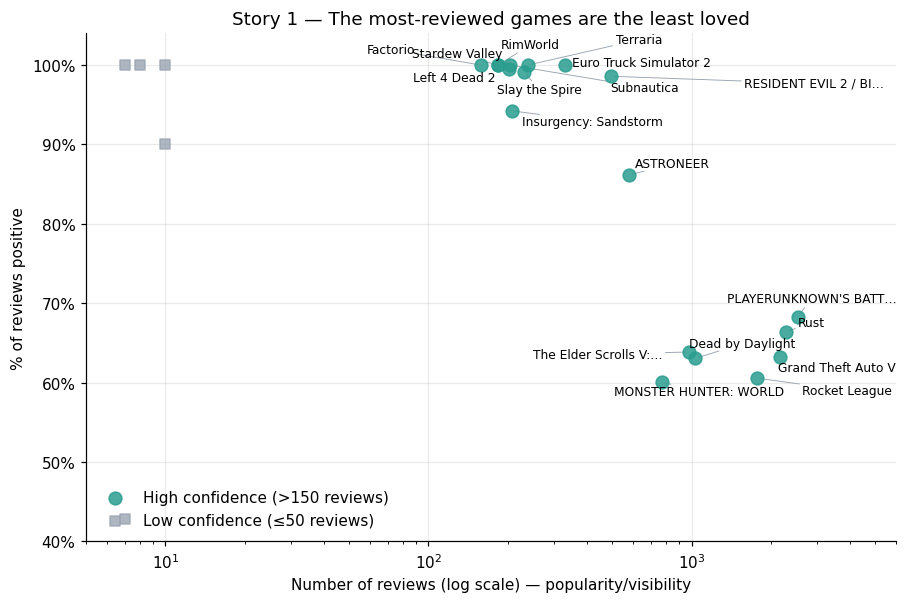

4 most-reviewed games: avg positivity 65%
High-confidence games at ≥98% positive: 9 (RESIDENT EVIL 2 / BIOHAZARD RE:2, Euro Truck Simulator 2, Terraria, Slay the Spire, Subnautica, Left 4 Dead 2) — avg 248 reviews each


In [3]:
fig, ax = plt.subplots(figsize=(9.5, 6))
hi = g[g['confidence'] == 'High']
lo = g[g['confidence'] == 'Low']

ax.scatter(hi['n_reviews'], hi['pos_rate'] * 100, s=70, c=C_POS, alpha=.85,
           label='High confidence (>150 reviews)', zorder=3)
ax.scatter(lo['n_reviews'], lo['pos_rate'] * 100, s=45, c=C_MUT, alpha=.8, marker='s',
           label='Low confidence (≤50 reviews)', zorder=3)

ax.set_xscale('log')
ax.set_xlim(5, 6000)
ax.set_ylim(40, 104)

texts = []
for t, r in g.iterrows():
    if r['n_reviews'] >= 150:
        short = t if len(t) <= 22 else t[:20] + '…'
        texts.append(ax.text(r['n_reviews'], r['pos_rate'] * 100, short, fontsize=8))
adjust_text(texts, ax=ax, expand=(1.15, 1.6), ensure_inside_axes=True,
            arrowprops=dict(arrowstyle='-', color='#9aa5b1', lw=.6))

ax.set_xscale('log')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Number of reviews (log scale) — popularity/visibility')
ax.set_ylabel('% of reviews positive')
ax.set_title('Story 1 — The most-reviewed games are the least loved')
ax.legend(loc='lower left', frameon=False)
save(fig, '01_popularity_vs_positivity')
plt.show()

big4 = g.loc[["PLAYERUNKNOWN'S BATTLEGROUNDS", 'Rust', 'Grand Theft Auto V', 'Rocket League']]
mid = g[(g['pos_rate'] >= 0.98) & (g['n_reviews'] >= 150)]
print(f"4 most-reviewed games: avg positivity {big4['pos_rate'].mean():.0%}")
print(f"High-confidence games at ≥98% positive: {len(mid)} "
      f"({', '.join(mid.index[:6])}) — avg {mid['n_reviews'].mean():.0f} reviews each")

**What was found.** Volume and approval don't merely fail to agree — in this catalogue they are
inverted. Every game with 1,700+ reviews sits at 60–68% positive; a cluster of mid-volume
games (150–350 reviews) sits at 98–100%. The "popular AND loved" corner of the chart is empty.


## What does playtime show that a rating can't?


saved figures/02_hours_vs_positivity.png


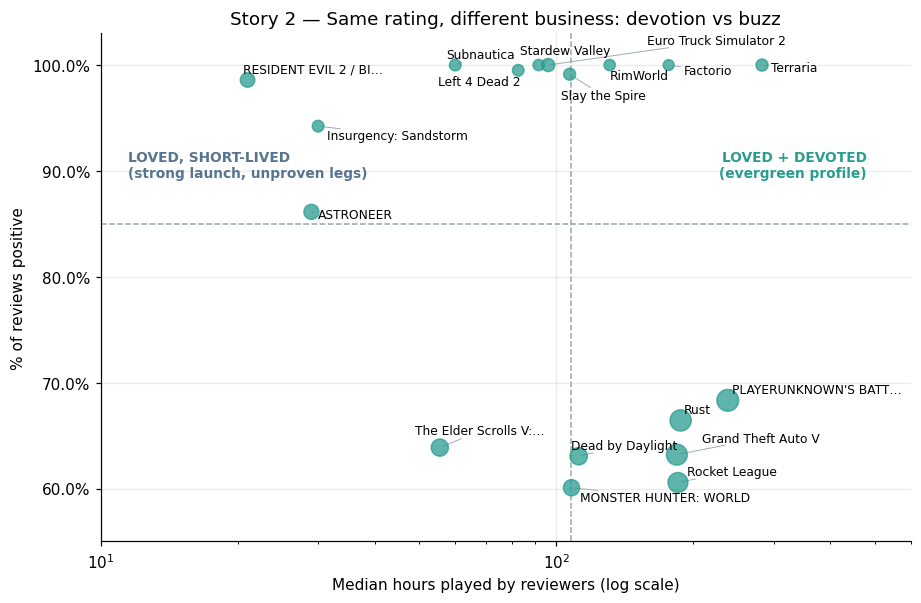

Terraria: 100% positive | median 283h | review history spans 7.6 years
RESIDENT EVIL 2 / BIOHAZARD RE:2: 99% positive | median 21h | review history spans 0.1 years


In [4]:
fig, ax = plt.subplots(figsize=(9.5, 6))
gg = g[g['confidence'] == 'High']
sizes = np.sqrt(gg['n_reviews']) * 4

ax.scatter(gg['median_hours'], gg['pos_rate'] * 100, s=sizes, c=C_POS, alpha=.75, zorder=3)
ax.set_xscale('log')
ax.set_xlim(10, 600)
ax.set_ylim(55, 103)

texts = []
for t, r in gg.iterrows():
    short = t if len(t) <= 22 else t[:20] + '…'
    texts.append(ax.text(r['median_hours'], r['pos_rate'] * 100, short, fontsize=8))
adjust_text(texts, ax=ax, expand=(1.15, 1.6), ensure_inside_axes=True,
            arrowprops=dict(arrowstyle='-', color='#9aa5b1', lw=.6))

med_h = gg['median_hours'].median()
ax.axvline(med_h, color=C_MUT, ls='--', lw=1)
ax.axhline(85, color=C_MUT, ls='--', lw=1)
ax.text(480, 92, 'LOVED + DEVOTED\n(evergreen profile)',
        ha='right', va='top', fontsize=9, color=C_POS, fontweight='bold')
ax.text(11.5, 92, 'LOVED, SHORT-LIVED\n(strong launch, unproven legs)',
        ha='left', va='top', fontsize=9, color='#577590', fontweight='bold')

ax.set_xscale('log')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Median hours played by reviewers (log scale)')
ax.set_ylabel('% of reviews positive')
ax.set_title('Story 2 — Same rating, different business: devotion vs buzz')
ax.set_ylim(55, 103)
save(fig, '02_hours_vs_positivity')
plt.show()

for t in ['Terraria', 'RESIDENT EVIL 2 / BIOHAZARD RE:2']:
    r = g.loc[t]
    print(f"{t}: {r['pos_rate']:.0%} positive | median {r['median_hours']:.0f}h "
          f"| review history spans {r['span_years']} years")

**What we found.** They don't. Terraria and Resident Evil 2 are both ~99–100% positive —
indistinguishable by rating, yet Terraria's median reviewer has **283 hours** across a
7.6-year history while RE2's has **21 hours** across 23 days. One is devotion, the other a
(great) launch with no evidence yet of staying power.



## Is a lifetime average even safe to use?


In [ ]:
rows = []
for t, sub in df[df['confidence_tier'] == 'High'].groupby('title_clean'):
    q = sub.set_index('date')['rec'].resample('QE').agg(n='size', pos='mean')
    q = q[q['n'] >= 50]
    if len(q) < 4:
        continue  # need enough quarters to define "normal"
    typical = q['pos'].median()
    worst = (q['pos'] - typical).idxmin()
    rows.append({'game': t,
                 'typical_pos': typical,
                 'worst_quarter': str(worst.to_period('Q')),
                 'worst_pos': q.loc[worst, 'pos'],
                 'deviation': q.loc[worst, 'pos'] - typical,
                 'reviews_that_quarter': int(q.loc[worst, 'n']),
                 'typical_quarter_volume': int(q['n'].median())})

anom = (pd.DataFrame(rows).set_index('game')
          .sort_values('deviation'))
anom['volume_spike'] = (anom['reviews_that_quarter'] / anom['typical_quarter_volume']).round(1)
anom.round(2)

,typical_pos,worst_quarter,worst_pos,deviation,reviews_that_quarter,typical_quarter_volume,volume_spike
game,,,,,,,
Grand Theft Auto V,0.76,2017Q2,0.24,-0.52,577,93,6.2
The Elder Scrolls V: Skyrim Special Edition,0.68,2017Q3,0.36,-0.32,73,80,0.9
Rocket League,0.60,2018Q3,0.37,-0.23,108,114,0.9
PLAYERUNKNOWN'S BATTLEGROUNDS,0.69,2018Q3,0.48,-0.20,166,298,0.6
Dead by Daylight,0.61,2016Q3,0.53,-0.08,127,85,1.5
Rust,0.62,2017Q3,0.56,-0.07,97,102,1.0
ASTRONEER,0.86,2018Q1,0.83,-0.03,52,103,0.5


**Something interesting** with Grand Theft Auto V in Q2 2017. Its positivity score dropped by more than 50 points compared to its usual level, while the number of reviews was about six times higher than normal.

After some Googling and looking at the dataset. The data shows. Most of the negative reviews during the unusual quarter were about the modding controversy. Words such as mods, Rockstar, Take-Two, and OpenIV appeared frequently, and 77% of the negative reviews mentioned the issue, compared to only 38% during other periods. Players were protesting Take-Two's attempt to shut down OpenIV, a popular modding tool for GTA V. When the decision was partly reversed a few weeks later, review sentiment recovered.

This had a major impact on the numbers. That single quarter accounted for 27% of all GTA V reviews and reduced the game's overall positivity score from 77% to 63%.

## Who is gaining steam, and who is losing it?



saved figures/04_momentum.png


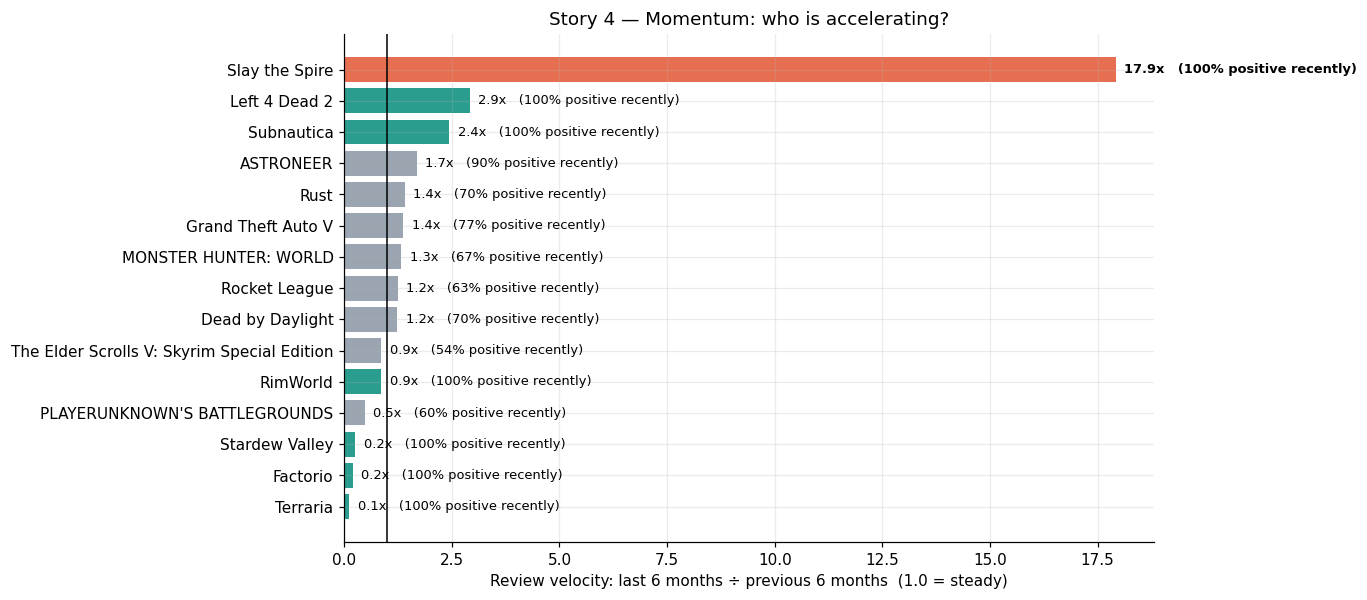

Excluded from the ratio chart (new releases — no prior-period reviews to compare against):
                                  recent_n  recent_pos
title_clean                                           
Insurgency: Sandstorm                  208        0.94
RESIDENT EVIL 2 / BIOHAZARD RE:2       496        0.99


In [8]:
cutoff = df['date'].max()
recent = df[df['date'] >= cutoff - pd.Timedelta(days=180)]
prior = df[(df['date'] < cutoff - pd.Timedelta(days=180)) &
           (df['date'] >= cutoff - pd.Timedelta(days=360))]

mom = pd.DataFrame({
    'recent_n': recent.groupby('title_clean')['rec'].size(),
    'recent_pos': recent.groupby('title_clean')['rec'].mean(),
    'prior_n': prior.groupby('title_clean')['rec'].size(),
}).fillna(0)
mom['ratio'] = mom['recent_n'] / mom['prior_n'].replace(0, np.nan)  # NaN = new release (no prior window)
mom = mom.join(g['confidence'])

est = mom[(mom['confidence'] == 'High') & mom['ratio'].notna()].sort_values('ratio')

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [C_NEG if t == 'Slay the Spire' else (C_POS if r['recent_pos'] >= .9 else C_MUT)
          for t, r in est.iterrows()]
ax.barh(est.index, est['ratio'], color=colors)
ax.axvline(1, color='k', lw=1)
ax.set_xlabel('Review velocity: last 6 months ÷ previous 6 months  (1.0 = steady)')
ax.set_title('Story 4 — Momentum: who is accelerating?')
for t, r in est.iterrows():
    ax.text(r['ratio'] + .2, t, f"{r['ratio']:.1f}x   ({r['recent_pos']:.0%} positive recently)",
            va='center', fontsize=8.5, fontweight='bold' if t == 'Slay the Spire' else 'normal')
save(fig, '04_momentum')
plt.show()

new_releases = mom[mom['ratio'].isna() & (mom['recent_n'] > 50)]
print("Excluded from the ratio chart (new releases — no prior-period reviews to compare against):")
print(new_releases[['recent_n', 'recent_pos']].round(2))

**What we found.** One bar dwarfs the chart: Slay the Spire's review velocity grew ~**18x**
while holding ~99% positive — it left early access in this window and caught fire with zero
quality compromise. Everything else sits between 0.1x and ~3x.



## Do zero-hour reviews behave like everyone else's?


saved figures/05_zero_hour_protest.png


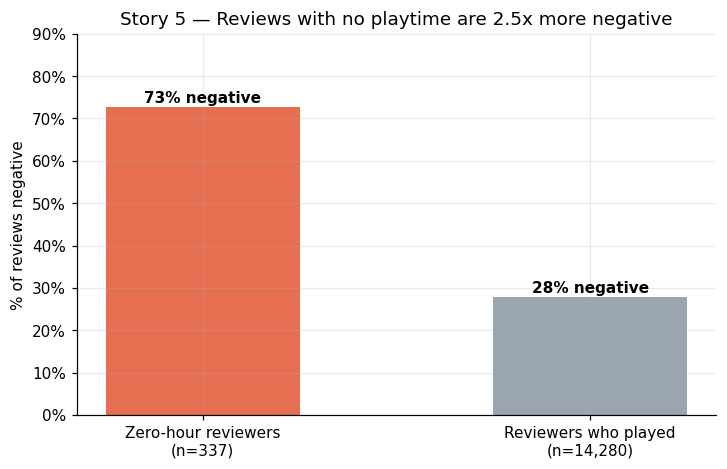

Zero-hour: 73% negative vs 28% for players with hours


In [9]:
zero = df[df['flag_zero_hours']]
played = df[~df['flag_zero_hours']]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cats = ['Zero-hour reviewers\n(n=337)', 'Reviewers who played\n(n=14,280)']
neg_shares = [1 - zero['rec'].mean(), 1 - played['rec'].mean()]
bars = ax.bar(cats, [v * 100 for v in neg_shares], color=[C_NEG, C_MUT], width=.5)
for b, v in zip(bars, neg_shares):
    ax.text(b.get_x() + b.get_width() / 2, v * 100 + 1, f'{v:.0%} negative',
            ha='center', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% of reviews negative')
ax.set_title('Story 5 — Reviews with no playtime are 2.5x more negative')
ax.set_ylim(0, 90)
save(fig, '05_zero_hour_protest')
plt.show()

print(f"Zero-hour: {1 - zero['rec'].mean():.0%} negative vs {1 - played['rec'].mean():.0%} for players with hours")

**What we found.** They don't look remotely like the rest: zero-hour reviewers are **73%
negative** vs 29% for everyone else, a refund-and-review / protest pattern, not a measurement
of the game. Who reviews matters, not just what they say.

## Summary — what we found, and where it goes next

Five questions in, five usable findings out:

| # | Question we asked | Answer the data gave | Number to remember | Feeds into |
|---|---|---|---|---|
| 1 | Does popularity track approval? | No — inverted in this catalogue | top-4 games avg ~65% positive; 7 mid-size games ≥98% | score design: sentiment and volume as separate signals |
| 2 | What does playtime add? | It separates devotion from buzz | Terraria 283h vs RE2 21h, both ~99% positive | deep-engagement component |
| 3 | Are lifetime averages safe? | No — one protest quarter distorts GTA V's | Q2-2017: 24% positive; lifetime 63% vs 77% without it | stability component + anomaly flags |
| 4 | Who is accelerating? | Slay the Spire, dramatically | ~18x velocity at ~99% positive | momentum component (new releases handled separately) |
| 5 | Do zero-hour reviews behave normally? | No — they're protest votes | 73% negative vs 29% base rate | reviewer-credibility weighting |
